In [30]:
import numpy as np  #It is a faster array than list and performs faster calculation
import pandas as pd #to import the dataset and perform data manipulation
import matplotlib.pyplot as plt #Both are be using to present the data
import seaborn as sns #Both are be using to present the data
import re #for the data cleaning

import nltk #natural language processing
from nltk.corpus import stopwords #list or collection of word
import spacy #change all the words into base word
#wordcloud
from wordcloud import WordCloud
#It is going to use the words which are going to be frequently used and create a wordcloud with text represented in larger size for the larger words

#Now downloading the wordnet and stopword using nltk
nltk.download('stopwords')
nltk.download('wordnet') #It is going to create a network around the the words

#time to create vector
from sklearn.feature_extraction.text import CountVectorizer #It is going to count the words aka Vectorization
#from sklearn.model_selection import GridSearchCV #To perform the hyperparameter tuning on random forest to find the best parameter value





from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import HalvingGridSearchCV




#Grid search CV can also use extra search cv
from sklearn.ensemble import RandomForestClassifier

#Evaluation Metrics
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report#To get all the precision and recall
from sklearn.metrics import ConfusionMatrixDisplay #To plot the confusion matrix

[nltk_data] Error loading stopwords: <urlopen error [Errno 11001]
[nltk_data]     getaddrinfo failed>
[nltk_data] Error loading wordnet: <urlopen error [Errno 11001]
[nltk_data]     getaddrinfo failed>


In [17]:
nlp = spacy.load("en_core_web_sm")

In [18]:
df_train=pd.read_csv('train.txt',delimiter=";",names=['text','label'])
df_val=pd.read_csv('val.txt',delimiter=";",names=['text','label'])

In [19]:
df=pd.concat([df_train,df_val]) #This concatinates both train validation dataset
df.reset_index(inplace=True,drop=True) #This changes the index value that are going to show error after concat in series

In [20]:
df.label.unique() #to get all the unique emotions

<StringArray>
['sadness', 'anger', 'love', 'surprise', 'fear', 'joy']
Length: 6, dtype: str

<Axes: ylabel='label'>

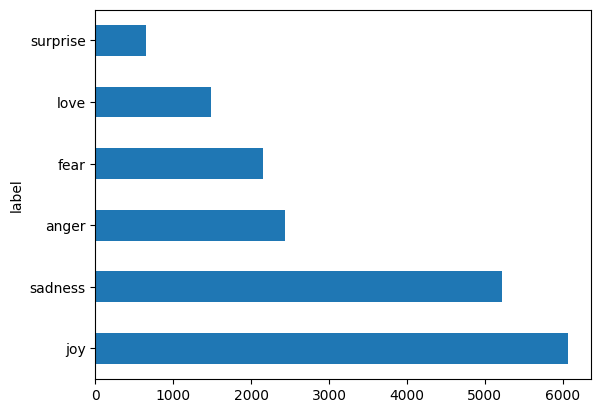

In [21]:
df.label.value_counts().plot.barh() #counting for every emotion and showcasing

In [22]:
df['label'].replace(to_replace=['surprise','joy','love'],value=1,inplace=True)
df['label'].replace(to_replace=['fear','anger','sadness'],value=0,inplace=True)

C:\Users\Ayush Sharma\AppData\Local\Temp\ipykernel_4624\1256568647.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['label'].replace(to_replace=['surprise','joy','love'],value=1,inplace=True)
C:\Users\Ayush Sharma\AppData\Local\Temp\ipykernel_4624\1256568647.py:2: ChainedAssignmentError: A value is being set on a copy of a Data

0           0
1           0
2           0
3        love
4           0
         ... 
17995       0
17996     joy
17997     joy
17998     joy
17999     joy
Name: label, Length: 18000, dtype: object

In [23]:
#creating function for removing the stop words as well as converting words into its base form by converting whole text into proper strings without any number or symbol
def transformation(df_columns):
  output = []
  for text_item in df_columns:
    # 1. Clean the raw text (remove non-alphabetic, lowercase)
    cleaned_text = re.sub('[^a-zA-Z]', ' ', str(text_item))
    cleaned_text = cleaned_text.lower()

    # 2. Process the cleaned text with spaCy
    doc = nlp(cleaned_text)

    # 3. Extract lemmas, filtering out stopwords, punctuation, spaces, and single-character words
    cleaned_tokens = []
    for token in doc:
      # Check if it's a stopword, punctuation, or whitespace and ensure text is not empty
      if not token.is_stop and not token.is_punct and not token.is_space and token.text.strip() != '':
        # Lowercase the lemma to ensure consistency
        lemma = token.lemma_.lower().strip()
        # Add condition to ensure lemma is not empty and has length > 1
        if lemma and len(lemma) > 2:
          cleaned_tokens.append(lemma)

    # 4. Join back into a string
    output.append(' '.join(cleaned_tokens))
  return output

In [24]:
var=transformation(df.text)

In [25]:
word=''
for i in var:
  for j in i:
    word+=' '.join(j)


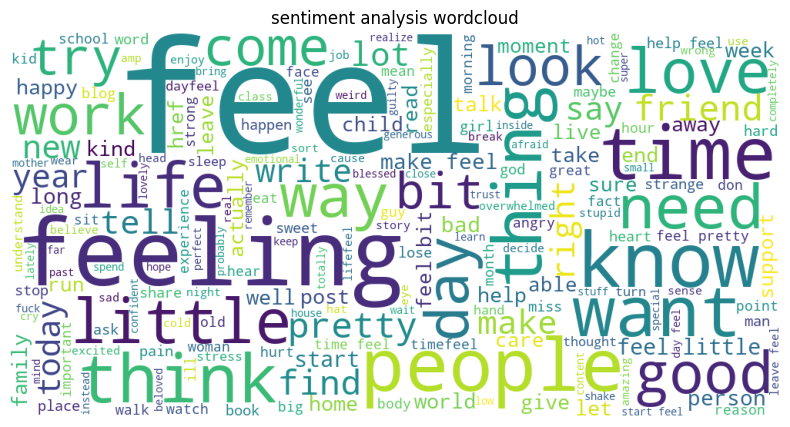

In [26]:
wordcloud = WordCloud(width=1000, height=500, background_color='white',min_font_size=10).generate(word)
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud)
plt.axis('off')  
plt.title("sentiment analysis wordcloud")
plt.show()

In [27]:
cv=CountVectorizer(ngram_range=(1,2))
traindata=cv.fit_transform(var)
x_train=traindata
y_train=df.label

In [34]:
model = RandomForestClassifier(n_jobs=-1, random_state=42)
parameters = {
    # 1. REMOVE 'auto'. In modern scikit-learn, 'auto' is deprecated or identical to 'sqrt'.
    'max_features': ['sqrt'], 
    
    # 2. DROP 1000 and 1500. Random Forest performance plateaus after 100-200 trees.
    # More trees only add time, not accuracy.
    'n_estimators': [100, 200], 
    
    # 3. KEEP None out for now. 'None' allows trees to grow infinitely, consuming massive RAM.
    'max_depth': [5, 10, 20], 
    
    'min_samples_leaf': [1, 2, 5],
    'min_samples_split': [5, 10],
    'bootstrap': [True]
}


In [35]:
grid_search = HalvingGridSearchCV(
    model, 
    parameters, 
    cv=5, 
    factor=3,        # Controls how many candidates are eliminated each round
    n_jobs=-1, 
    random_state=42
)
grid_search.fit(x_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (string) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'bootstrap': [True], 'max_depth': [5, 10, ...], 'max_features': ['sqrt'], 'min_samples_leaf': [1, 2, ...], ...}"
,"factor factor: int or float, default=3The 'halving' parameter, which determines the proportion of candidatesthat are selected for each subsequent iteration. For example,``factor=3`` means that only one third of the candidates are selected.",3
,"resource resource: ``'n_samples'`` or str, default='n_samples'Defines the resource that increases with each iteration. By default,the resource is the number of samples. It can also be set to anyparameter of the base estimator that accepts positive integervalues, e.g. 'n_iterations' or 'n_estimators' for a gradientboosting estimator. In this case ``max_resources`` cannot be 'auto'and must be set explicitly.",'n_samples'
,"max_resources max_resources: int, default='auto'The maximum amount of resource that any candidate is allowed to usefor a given iteration. By default, this is set to ``n_samples`` when``resource='n_samples'`` (default), else an error is raised.",'auto'
,"min_resources min_resources: {'exhaust', 'smallest'} or int, default='exhaust'The minimum amount of resource that any candidate is allowed to usefor a given iteration. Equivalently, this defines the amount ofresources `r0` that are allocated for each candidate at the firstiteration.- 'smallest' is a heuristic that sets `r0` to a small value: - ``n_splits * 2`` when ``resource='n_samples'`` for a regression problem - ``n_classes * n_splits * 2`` when ``resource='n_samples'`` for a classification problem - ``1`` when ``resource != 'n_samples'``- 'exhaust' will set `r0` such that the **last** iteration uses as much resources as possible. Namely, the last iteration will use the highest value smaller than ``max_resources`` that is a multiple of both ``min_resources`` and ``factor``. In general, using 'exhaust' leads to a more accurate estimator, but is slightly more time consuming.Note that the amount of resources used at each iteration is always amultiple of ``min_resources``.",'exhaust'
,"aggressive_elimination aggressive_elimination: bool, default=FalseThis is only relevant in cases where there isn't enough resources toreduce the remaining candidates to at most `factor` after the lastiteration. If ``True``, then the search process will 'replay' thefirst iteration for as long as needed until the number of candidatesis small enough. This is ``False`` by default, which means that thelast iteration may evaluate more than ``factor`` candidates. See:ref:`aggressive_elimination` for more details.",False
,"cv cv: int, cross-validation generator or iterable, default=5Determines the cross-validation splitting strategy.Possible inputs for cv are:- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... note:: Due to implementation details, the folds produced by `cv` must be the same across multiple calls to `cv.split()`. For built-in `scikit-learn` iterators, this can be achieved by deactivating shuffling (`shuffle=False`), or by 

In [ ]:
grid_search.best_params_
rfc=RandomForestClassifier(max_features=grid_search.best_params_['max_features'],
                            n_estimators=grid_search.best_params_['n_estimators'],
                            max_depth=grid_search.best_params_['max_depth'],
                            min_samples_leaf=grid_search.best_params_['min_samples_leaf'],
                            min_samples_split=grid_search.best_params_['min_samples_split'],
                            bootstrap=grid_search.best_params_['bootstrap'])